# Choosing a corrector: `AutoCorrector` and `BatchCorrectionBenchmark`

MaldiBatchKit ships several correctors with overlapping use cases. Two v0.2 classes turn the *which one should I use?* question into an automated, scikit-learn-shaped workflow:

* [`AutoCorrector`](https://maldibatchkit.readthedocs.io/en/latest/api/corrections.html#maldibatchkit.AutoCorrector) exposes the correction method itself as a settable hyperparameter, so a single `GridSearchCV` can sweep across corrector families and let the **downstream classifier metric** (typically AUROC) pick the winner.
* [`BatchCorrectionBenchmark`](https://maldibatchkit.readthedocs.io/en/latest/api/diagnostics.html#maldibatchkit.diagnostics.BatchCorrectionBenchmark) runs a fixed set of **batch-mixing diagnostics** across multiple correctors under a single protocol, with bootstrap confidence intervals.

The two tools answer **different** questions; pick the one that matches the decision you actually need to make.

Uses the **MALDI-Kleb-AI** dataset (Rocchi *et al.* 2026, [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)).

## 1. Load the dataset

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from notebooks._demo import load_maldi_kleb_ai

demo = load_maldi_kleb_ai(antibiotic='Amikacin')
X = demo.X
batch = demo.batch          # Rome / Milan / Catania
species = demo.species      # K. pneumoniae / K. variicola / ...
quality = demo.meta['SNR']  # signal-to-noise ratio per spectrum
y = (demo.meta['Amikacin'] == 'R').astype(int)

print(f'X:       {X.shape}')
print(f'batches: {sorted(batch.unique())}')
print(f'species: {sorted(species.unique())}')
print(f'prevalence of resistance: {y.mean():.2%}')

X:       (741, 6000)
batches: ['Catania', 'Milan', 'Rome']
species: ['Klebsiella aerogenes', 'Klebsiella oxytoca', 'Klebsiella pneumoniae', 'Klebsiella variicola']
prevalence of resistance: 49.80%


## 2. `AutoCorrector` - swap the method as a hyperparameter

`AutoCorrector` is a thin `BaseBatchCorrector` whose `method` argument selects an inner corrector at `fit` time. It accepts string aliases (`'combat-fortin'`, `'harmony'`, `'qw-combat'`, `'noop'`, ...) **or** a `BaseBatchCorrector` subclass. Covariates are routed to whatever the inner method actually understands:

* `discrete_covariates` → ComBat's `discrete_covariates`, Harmony's   `covariates`, Limma's `design`,
* `continuous_covariates` → ComBat only,
* `quality` → `QualityWeightedComBat.quality`,
* `species` → `SpeciesAwareComBat.species`.

Anything the inner does not accept is dropped silently (sklearn convention), so the same `param_grid` can target multiple methods.

In [2]:
import warnings
from maldibatchkit import AutoCorrector

ac = AutoCorrector(
    batch=batch,
    method='combat-fortin',
    discrete_covariates=species,
    quality=quality,          # ignored by combat-fortin
)
ac.fit(X)
print('inner class:', type(ac.inner_).__name__)

# Switch to QualityWeightedComBat. `quality=` is now consumed;
# `discrete_covariates=` is the one being dropped. AutoCorrector
# emits a UserWarning for every dropped kwarg; we capture it here
# explicitly so the demo output stays tidy.
ac.set_params(method='qw-combat')
with warnings.catch_warnings(record=True) as wlog:
    warnings.simplefilter('always')
    ac.fit(X)
print('inner class:', type(ac.inner_).__name__)
print('dropped kwargs warnings:')
for w in wlog:
    print(' -', w.message)
print('gamma_star_ shape (mirrored via __getattr__):', ac.gamma_star_.shape)

inner class: ComBat


inner class: QualityWeightedComBat
dropped kwargs warnings:
 - method='qw-combat' does not accept discrete covariates; ignoring `discrete_covariates`.
gamma_star_ shape (mirrored via __getattr__): (3, 6000)


### 2.1. Cross-validated per-batch AUROC

Overall AUROC can hide site-specific failures: a model can score 0.80 overall while being near-random on the smallest site. If a corrector truly removes batch effect *useful for the task*, the **per-batch AUROC** should tighten around the overall value rather than diverge across the three sites.

We run a 5-fold CV stratified jointly by `batch × y`, so every fold sees the same per-site resistance prevalence. For each method we score AUROC per batch in the held-out fold, then aggregate across folds.

In [3]:
import warnings
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

methods = ['noop', 'median', 'combat-fortin', 'harmony']

base_pipe = Pipeline([
    ('correct', AutoCorrector(batch=batch,
                              discrete_covariates=species,
                              method_kwargs={'verbose': False,
                                             'random_state': 0,
                                             'n_components': 30})),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=0.1, n_jobs=1)),
])

# Combine batch and outcome into a single stratification label so each
# fold sees the same per-site resistance prevalence.
strat = batch.astype(str) + '|' + y.astype(str)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

records = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for fold, (tr, te) in enumerate(cv_strat.split(X, strat)):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        b_te = batch.iloc[te].to_numpy()
        for m in methods:
            pipe = clone(base_pipe)
            pipe.set_params(correct__method=m)
            pipe.fit(X_tr, y_tr)
            proba = pipe.predict_proba(X_te)[:, 1]
            # overall fold AUROC
            records.append({
                'method': m, 'batch': '(overall)', 'fold': fold,
                'n': len(y_te), 'prev': float(y_te.mean()),
                'auc': roc_auc_score(y_te, proba),
            })
            # per-batch AUROC
            for lvl in sorted(batch.unique()):
                mask = b_te == lvl
                y_lvl = y_te.iloc[mask]
                if mask.sum() < 5 or y_lvl.nunique() < 2:
                    auc = np.nan
                else:
                    auc = roc_auc_score(y_lvl, proba[mask])
                records.append({
                    'method': m, 'batch': lvl, 'fold': fold,
                    'n': int(mask.sum()),
                    'prev': float(y_lvl.mean()) if mask.any() else np.nan,
                    'auc': auc,
                })

per_batch = pd.DataFrame(records)
summary = (per_batch
           .groupby(['method', 'batch'])['auc']
           .agg(['mean', 'std'])
           .round(4)
           .reset_index())
auc_pivot = summary.pivot(index='method', columns='batch', values='mean')
auc_pivot = auc_pivot.reindex(methods)        # keep our method order
auc_pivot = auc_pivot[sorted(batch.unique()) + ['(overall)']]
auc_pivot.round(4)

batch,Catania,Milan,Rome,(overall)
method,,,,
noop,0.8980,0.8258,0.6991,0.8147
median,0.8825,0.7902,0.7070,0.8129
combat-fortin,0.7995,0.8299,0.7021,0.7456
harmony,0.7588,0.6853,0.6439,0.7768


In [4]:
# Spread across sites: range and standard deviation of the three
# per-batch AUROCs (smaller = better aligned).
per_site = auc_pivot.drop(columns='(overall)')
alignment = pd.DataFrame({
    'mean_per_site': per_site.mean(axis=1).round(4),
    'range':         (per_site.max(axis=1) - per_site.min(axis=1)).round(4),
    'std':           per_site.std(axis=1).round(4),
    'overall':       auc_pivot['(overall)'].round(4),
})
alignment.sort_values('range')

,mean_per_site,range,std,overall
method,,,,
harmony,0.6960,0.1149,0.0582,0.7768
combat-fortin,0.7772,0.1278,0.0668,0.7456
median,0.7932,0.1755,0.0878,0.8129
noop,0.8076,0.1989,0.1007,0.8147


### 2.2. Picking the winner with `make_batch_scorer`

The manual CV table above is informative but tedious. `maldibatchkit.metrics` ships `make_batch_scorer`, which packages a per-batch metric with a chosen across-batch aggregation as a sklearn scorer. Drop it into `GridSearchCV(scoring=...)` and the right corrector falls out automatically.

The `weights=` argument controls how the per-batch scalars are aggregated:

* `weights='size'` weights each site by its sample count.   For *additive* metrics whose definition is `correct / total`   (accuracy, error rate), this exactly recovers the standard   pooled value. For metrics with a *class-conditional*   denominator (sensitivity, specificity), recovering the pooled   value needs class-conditional weights, not size weights. For   *non-linear* metrics (F1, precision, MCC, balanced accuracy),   no per-batch weighting recovers pooled exactly. For AUROC   and average precision, pooled values count cross-batch   positive-vs-negative pairs that any per-batch reducer   **cannot see by construction** - they are gone, not   approximated. In every non-additive case the dominant site   still dominates the score in the same direction.
* `weights='uniform'` gives each site equal weight - one vote per   site - so a corrector that bombs on a small site is properly   penalised. The right choice when the goal is a classifier that   *generalises across sites*.
* `weights='balanced'` weights each site **inversely** by its sample   count (`w_i ∝ 1 / n_i`), mirroring sklearn's `class_weight='balanced'`   formula at the per-batch level. The smallest site gets the loudest   voice. Use this when minority sites are the hardest distributions   to learn and the corrector must not crush them.
* a `{batch_label: weight}` dict lets you encode any custom policy.

Switching weighting modes typically picks **different** winners, which is exactly the trade-off we want the user to make explicit.

In [5]:
from maldibatchkit.metrics import make_batch_scorer
from sklearn.model_selection import GridSearchCV

# Materialise the CV folds once so both grid searches see the same
# train / test splits (cv_strat.split returns a one-shot generator).
folds = list(cv_strat.split(X, strat))

weight_modes = ('size', 'uniform', 'balanced')
picks = {}
for weights_mode in weight_modes:
    scorer = make_batch_scorer(batch, metric='roc_auc', weights=weights_mode)
    grid = GridSearchCV(
        base_pipe,
        param_grid={'correct__method': methods},
        scoring=scorer,
        cv=folds,
        n_jobs=1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        grid.fit(X, y)
    picks[weights_mode] = (
        pd.DataFrame(grid.cv_results_)
          [['param_correct__method', 'mean_test_score', 'std_test_score']]
          .rename(columns={
              'param_correct__method': 'method',
              'mean_test_score': f'mean_{weights_mode}',
              'std_test_score':  f'std_{weights_mode}',
          })
    )

comparison = picks['size']
for m in ('uniform', 'balanced'):
    comparison = comparison.merge(picks[m], on='method')
comparison = (comparison
              .sort_values('mean_uniform', ascending=False)
              .reset_index(drop=True)
              .round(4))
comparison

,method,mean_size,std_size,mean_uniform,std_uniform,mean_balanced,std_balanced
0,noop,0.7541,0.0495,0.8076,0.0527,0.8550,0.0626
1,median,0.7484,0.0570,0.7932,0.0593,0.8363,0.0673
2,combat-fortin,0.7451,0.0232,0.7772,0.0275,0.7975,0.0723
3,harmony,0.6678,0.0184,0.6960,0.0458,0.7246,0.0640


In [6]:
# Which corrector each weighting mode picks (best mean score).
winners = {
    mode: df.set_index('method')[f'mean_{mode}'].idxmax()
    for mode, df in picks.items()
}
winners

{'size': 'noop', 'uniform': 'noop', 'balanced': 'noop'}

## 3. `BatchCorrectionBenchmark` - diagnostic comparison

`BatchCorrectionBenchmark` is the diagnostic counterpart: configure once, then `.fit(X, batch=..., species=...)` to score every corrector against every metric. It is **diagnostic-only by design** - no downstream classifier is involved. The output is a tidy `(method, metric, value, ci_lo, ci_hi, std, n, better)` table ready for paper-figure comparisons.

Bootstrap confidence intervals are stratified by batch:

* `bootstrap_mode='resample_metric'` (default, fast) - fit each corrector   once, resample rows of the corrected matrix to give the CI.
* `bootstrap_mode='refit'` (slower) - resample rows of `X` and refit per   bootstrap iteration. The CI then also captures corrector stability.

In [7]:
from maldibatchkit import (
    ComBat, Harmony, Limma, NoOpCorrector, QualityWeightedComBat, SpeciesAwareComBat,
)
from maldibatchkit.diagnostics import BatchCorrectionBenchmark

bench = BatchCorrectionBenchmark(
    correctors={
        'none':           NoOpCorrector(batch=batch),
        'limma':          Limma(batch=batch, design=pd.get_dummies(species).astype(float)),
        'combat-johnson': ComBat(batch=batch, method='johnson'),
        'combat-fortin':  ComBat(batch=batch, method='fortin',
                                 discrete_covariates=species),
        'species-combat': SpeciesAwareComBat(batch=batch, species=species),
        'qw-combat':      QualityWeightedComBat(batch=batch, quality=quality),
        'harmony':        Harmony(batch=batch, covariates=species,
                                  n_components=30, verbose=False,
                                  random_state=0),
    },
    metrics=(
        'silhouette_batch',
        'kbet',
        'lisi_normalized',
        'species_preservation',
    ),
    n_bootstrap=50,
    bootstrap_mode='resample_metric',
    random_state=0,
)
bench.fit(X, batch=batch, species=species)
bench.results_.round(4)

,method,metric,value,ci_lo,ci_hi,std,n,better
0,none,silhouette_batch,0.1490,0.1408,0.1582,0.0054,51.0,zero
1,none,kbet,0.0212,0.0094,0.0364,0.0073,51.0,higher
2,none,lisi_normalized,0.4902,0.4842,0.4978,0.0039,51.0,higher
3,none,species_preservation,1.0000,1.0000,1.0000,0.0000,51.0,higher
4,limma,silhouette_batch,0.0279,0.0142,0.0435,0.0083,51.0,zero
5,limma,kbet,0.1032,0.0661,0.1248,0.0167,51.0,higher
6,limma,lisi_normalized,0.5146,0.5039,0.5280,0.0062,51.0,higher
7,limma,species_preservation,1.0000,1.0000,1.0000,0.0000,51.0,higher
8,combat-johnson,silhouette_batch,-0.0095,-0.0282,0.0051,0.0090,51.0,zero
9,combat-johnson,kbet,0.2338,0.1866,0.2871,0.0279,51.0,higher


Sort by any metric - `.rank()` follows the metric's registered direction (`'higher'` → descending, `'lower'` → ascending) by default. Here `species_preservation` ∈ [0, 1] where 1 means species are perfectly preserved after correction.

In [8]:
bench.rank('species_preservation').round(4)

,method,metric,value,ci_lo,ci_hi,std,n,better
0,none,species_preservation,1.0000,1.0000,1.0000,0.0000,51.0,higher
1,limma,species_preservation,1.0000,1.0000,1.0000,0.0000,51.0,higher
2,combat-fortin,species_preservation,0.9826,0.9444,1.0000,0.0186,51.0,higher
3,species-combat,species_preservation,0.9777,0.9361,1.0000,0.0232,51.0,higher
4,qw-combat,species_preservation,0.9218,0.8512,0.9892,0.0375,51.0,higher
5,combat-johnson,species_preservation,0.9156,0.8368,0.9773,0.0408,51.0,higher
6,harmony,species_preservation,0.7245,0.6017,0.8224,0.0646,51.0,higher


In [9]:
bench.rank('silhouette_batch').round(4)

,method,metric,value,ci_lo,ci_hi,std,n,better
0,combat-fortin,silhouette_batch,-0.0094,-0.0219,0.0018,0.0077,51.0,zero
1,combat-johnson,silhouette_batch,-0.0095,-0.0282,0.0051,0.0090,51.0,zero
2,qw-combat,silhouette_batch,0.0108,-0.0003,0.0196,0.0053,51.0,zero
3,species-combat,silhouette_batch,-0.0121,-0.0344,0.0032,0.0096,51.0,zero
4,limma,silhouette_batch,0.0279,0.0142,0.0435,0.0083,51.0,zero
5,harmony,silhouette_batch,0.0452,0.0336,0.0564,0.0065,51.0,zero
6,none,silhouette_batch,0.1490,0.1408,0.1582,0.0054,51.0,zero


The raw observations are kept in `results_long_` (one row per (method, metric, repeat, bootstrap)). The point estimate is marked `bootstrap == -1`; the resampled values are `bootstrap >= 0`. Use it to compute custom statistics or to drive a raincloud / strip plot.

In [10]:
bench.results_long_.head()

,method,metric,repeat,bootstrap,value
0,none,silhouette_batch,0,-1,0.147457
1,none,kbet,0,-1,0.020243
2,none,lisi_normalized,0,-1,0.484701
3,none,species_preservation,0,-1,1.000000
4,none,silhouette_batch,0,0,0.143741


In [11]:
# Baseline metrics on the *uncorrected* X (a useful reference line in plots).
bench.baseline_.round(4)

,method,metric,value,ci_lo,ci_hi,std,n,better
0,__baseline__,silhouette_batch,0.1475,NaN,NaN,NaN,1,zero
1,__baseline__,kbet,0.0202,NaN,NaN,NaN,1,higher
2,__baseline__,lisi_normalized,0.4847,NaN,NaN,NaN,1,higher
3,__baseline__,species_preservation,1.0000,NaN,NaN,NaN,1,higher


And the convenience `.plot()` helper, faceted by metric with the bootstrap CIs as error bars:

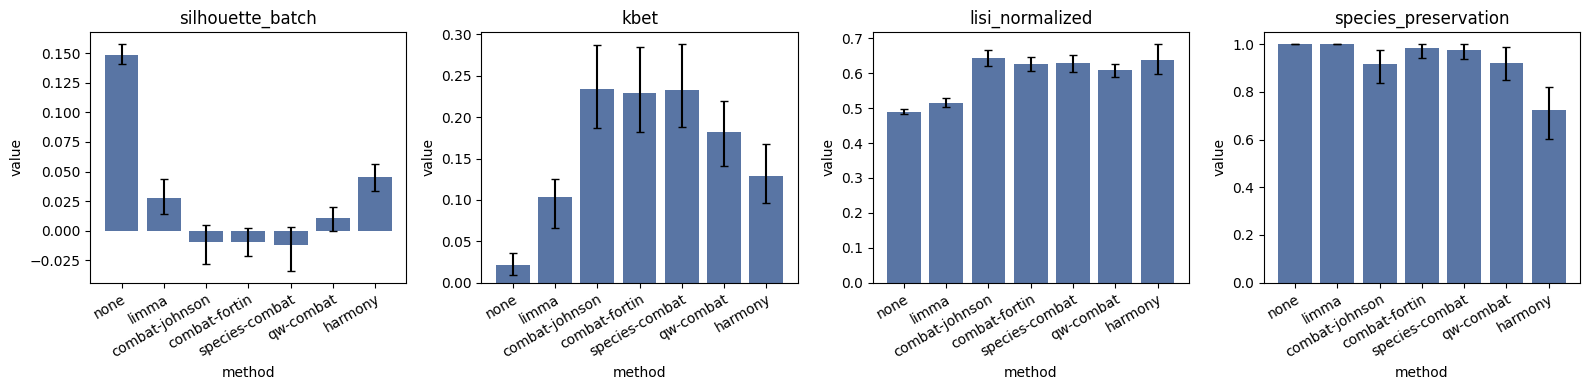

In [12]:
import matplotlib.pyplot as plt  # noqa: F401
%matplotlib inline
bench.plot();

## 4. Which tool when?

* **`AutoCorrector` inside a stratified CV loop** - when the question is *does this correction make my AMR classifier better, on every site?* The downstream classifier metric is the only honest arbiter of whether the correction step helps the task you actually care about. **Do not read only the overall AUROC**: stratify the held-out folds jointly by `batch × y` and look at the per-batch table. A method that 'improves' the mean while still leaving a large gap between sites is buying alignment at the cost of overall performance - or buying overall performance by riding site-specific signal that won't transfer.
* **`BatchCorrectionBenchmark`** - when the question is *which corrector mixes batches and preserves species best, independent of any classifier?* (method-comparison tables, deciding whether a corrector is blurring biology). Cheap, downstream-agnostic, and reproducible via the stratified bootstrap CIs.

### The two tools disagree on this cohort - and that disagreement *is* the lesson

The diagnostic table ranks ComBat variants on top: they flatten the batch axis, the LISI normalised score climbs, species preservation stays near-perfect. The per-batch AUROC table puts `noop` and `median` on top: the uncorrected matrix produces the highest mean per-site AUROC, *and* the widest cross-site spread.

That gap between the two verdicts is not a bug in either tool. It is the classic multi-centre clinical-AMR trap: **inter-site differences are partly the resistance signal itself** - different patient populations, different antibiograms, different colonisation pressure. Aggressive batch correction is mathematically obliged to strip that signal because the corrector has no way to know which inter-site differences are 'real' biology and which are technical drift.

MaldiBatchKit cannot make that decision for you. What it does is make the trade-off **legible**:

* The diagnostic table tells you *how much* a corrector flattens   the batch axis.
* The per-batch AUROC table tells you *what that flattening costs   on the task* and *whether the gain is uniform across sites*   (the `range` column in §2.1 shows correctors tighten cross-site   spread even when they cost overall AUROC).
* The clinical judgement - 'is the inter-site differential a bias   I want gone, or a signal I want kept?' - is yours.

A simple practical rule: if both rankings agree, ship the corrector. If they disagree, the cohort is site-confounded; validate on a truly *external* cohort (a 4th site never seen at fit time) before committing to any correction step in a clinical pipeline.

A diagnostic win does not imply a downstream win.

Neither tool simulates a new clinical site: both rely on every batch being present at `fit` time for the inter-batch correctors we ship.